##樹木檔案清理樹種
###第一步：檢索樹種總類與統計
為清理樹木清冊檔案，先統計檔案中存在的所有獨特樹種

In [ ]:
import pandas as pd
from IPython.display import display

def extract_unique_tree_species(file_name):
    """
    讀取 CSV 檔案，並萃取「樹種名稱」欄位的所有獨立值與出現次數。
    """
    try:
        # 1. 讀取 CSV 檔案 (指定 utf-8 編碼)
        print(f"正在讀取檔案: {file_name} ...")
        df = pd.read_csv(file_name, encoding='utf-8')

        # 2. 檢查「樹種名稱」欄位是否存在
        if '樹種名稱' not in df.columns:
            print("❌ 錯誤：在檔案中找不到「樹種名稱」這個欄位。")
            print("目前的欄位有：", df.columns.tolist())
            return

        # 3. 取得所有不同的樹種名稱，以及它們出現的總次數
        # value_counts() 會自動將數量最多的排在上面
        tree_counts = df['樹種名稱'].value_counts(dropna=False)

        # 4. 將結果整理成乾淨的 DataFrame 表格格式
        unique_trees_df = tree_counts.reset_index()
        unique_trees_df.columns = ['樹種名稱 (包含空值或錯字)', '出現次數']

        # 印出總結
        print(f"✅ 讀取成功！總共找到 {len(unique_trees_df)} 種不同的樹種名稱。\n")

        # 5. 在 Colab 中以互動式表格顯示 (這樣你可以輕鬆滑動瀏覽)
        display(unique_trees_df)

        # (選用) 將這份清單匯出成一個新的 CSV，方便你下載下來用 Excel 慢慢看並決定如何清理
        export_filename = '樹種名稱_獨立值清單.csv'
        unique_trees_df.to_csv(export_filename, index=False, encoding='utf-8-sig')
        print(f"\n💡 提示：我已經順便將這份清單儲存為 '{export_filename}'，你可以從左側檔案庫下載。")

    except FileNotFoundError:
        print(f"❌ 找不到檔案 '{file_name}'。")
        print("請確認你已經將檔案拖曳上傳到 Colab 左側的「檔案」區塊中，並且檔名完全正確。")
    except Exception as e:
        print(f"❌ 讀取檔案時發生錯誤: {e}")

# ==========================================
# 請確認你的檔名是否與下方字串完全一致 (包含 .csv 副檔名)
# ==========================================
csv_file_path = '台北市公園處&街樹綜整整理_清理後.csv'

# 執行函式
extract_unique_tree_species(csv_file_path)

正在讀取檔案: 台北市公園處&街樹綜整整理_清理後.csv ...
✅ 讀取成功！總共找到 483 種不同的樹種名稱。



/tmp/ipykernel_3366/2110648456.py:11: DtypeWarning: Columns (6,10,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_name, encoding='utf-8')


,樹種名稱 (包含空值或錯字),出現次數
0,榕樹,21928
1,茄苳,13555
2,樟樹,11911
3,楓香,9705
4,臺灣欒樹,8806
...,...,...
478,臺灣雅楠,1
479,圓葉橡膠樹,1
480,綠葉竹蕉,1
481,千年木,1



💡 提示：我已經順便將這份清單儲存為 '樹種名稱_獨立值清單.csv'，你可以從左側檔案庫下載。


###第二步：客製化清理
因中文用字不一的問題，僅能以人工方式校閱檔案，並篩選清理樹種


In [ ]:
import pandas as pd

def clean_tree_data(file_path):
    try:
        # 1. 讀取 CSV (指定 UTF-8 編碼)
        df = pd.read_csv(file_path, encoding='utf-8')
        print(f"原始資料筆數: {len(df)}")

        # 2. 前置處理：先去除「樹種名稱」欄位前後的空格 (解決如：”叢立孔雀椰子 “多一空格的問題)
        df['樹種名稱'] = df['樹種名稱'].astype(str).str.strip()

        # 3. 定義統一更名規則 (Mapping Dictionary)
        # 依照你的要求：舊名稱 -> 新名稱
        rename_rules = {
            "山柿": "山紅柿",
            "月橘 (七里香)": "月橘",
            "火燄木": "火焰木",
            "光蠟樹": "光臘樹",
            "李": "李樹",
            "杏": "杏樹",
            "亞力山大椰子": "亞歷山大椰子",
            "咖啡": "咖啡樹",
            "金剛篡": "金剛纂",
            "南洋含笑花": "南洋含笑",
            "垂葉榕": "垂榕",
            "柚": "柚子",
            "柳丁": "柳橙",
            "桃": "桃樹",
            "烏?": "烏臼",
            "裡白?木": "裡白楤木",
            "龍眼": "龍眼樹",
            "檬果": "芒果樹",
            "芒果": "芒果樹",
            "櫸": "櫸木",
            "欖仁": "欖仁樹",
            "艷紫荊": "豔紫荊"
        }

        # 執行統一更名
        df['樹種名稱'] = df['樹種名稱'].replace(rename_rules)

        # 4. 定義刪除規則 (Deletion List)
        # 依照你的要求：刪除 白?、枯枝、枯木
        delete_list = ["白?", "枯枝", "枯木"]

        # 進行過濾，只保留不在刪除名單中的資料
        df = df[~df['樹種名稱'].isin(delete_list)]

        # 5. 輸出清理後的總結
        print("--- 清理完成 ---")
        print(f"清理後的資料筆數: {len(df)}")
        print(f"已刪除筆數: {len(pd.read_csv(file_path)) - len(df)}")

        # 顯示清理後的前幾名樹種名稱，讓你確認結果
        print("\n清理後的前 20 名樹種名稱清單：")
        print(df['樹種名稱'].value_counts().head(20))

        # 6. 儲存結果
        output_file = '台北市公園處&街樹綜整整理_清理後.csv'
        df.to_csv(output_file, index=False, encoding='utf-8-sig')
        print(f"\n✅ 檔案已儲存為: {output_file}")

    except Exception as e:
        print(f"發生錯誤: {e}")

# ==========================================
# 執行清理
# ==========================================
csv_path = '台北市公園處&街樹統整清理.csv'
clean_tree_data(csv_path)

/tmp/ipykernel_3366/1655104580.py:6: DtypeWarning: Columns (6,10,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding='utf-8')


原始資料筆數: 160342
--- 清理完成 ---
清理後的資料筆數: 160342


/tmp/ipykernel_3366/1655104580.py:52: DtypeWarning: Columns (6,10,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  print(f"已刪除筆數: {len(pd.read_csv(file_path)) - len(df)}")


已刪除筆數: 0

清理後的前 20 名樹種名稱清單：
樹種名稱
榕樹      21928
茄苳      13555
樟樹      11911
楓香       9705
臺灣欒樹     8806
黑板樹      6935
白千層      5833
小葉欖仁     4419
水黃皮      3869
山櫻花      3084
大花紫薇     2873
大王椰子     2726
光臘樹      2502
苦楝       2340
木棉       2169
阿勃勒      2017
蒲葵       1812
垂榕       1673
榔榆       1651
菩提樹      1561
Name: count, dtype: int64

✅ 檔案已儲存為: 台北市公園處&街樹綜整整理_清理後.csv


##介接OSM公園圖資

### 第一步：介接 OSM API 獲取指定行政區之公園圖資 (Polygons)

本區塊將執行以下核心操作：
1. **環境建置**：安裝並載入 `osmnx` (負責與 OSM API 溝通) 與 `geopandas`。
2. **範圍界定**：讀取行政區 Shapefile，篩選出目標六區 (大同、萬華、中山、中正、松山、大安)，並透過 `dissolve` 融合出一個完整的大邊界。
3. **CRS 轉換**：將邊界轉換為 `EPSG:4326` (WGS84)，因為 OSM 系統統一使用此全球標準座標。
4. **介接下載**：使用 `osmnx.features_from_polygon`，指定標籤 `{'leisure': 'park'}` 來精準抓取公園設施。
5. **幾何過濾**：OSM 資料包含點 (如：單一樹木或打卡點)、線與面，我們在此過濾出 `Polygon` 與 `MultiPolygon` 的實體公園範圍。

In [ ]:
!pip install -q osmnx geopandas matplotlib

import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import osmnx as ox
import geopandas as gpd

print("⚙️ 正在初始化環境設定...")

# ==========================================
# 0. 解決字體與警告問題 (最優先執行)
# ==========================================
warnings.filterwarnings("ignore", category=UserWarning)

font_path = '/tmp/NotoSansTC.otf'
if not os.path.exists(font_path):
    !wget -q -O {font_path} https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf

fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Noto Sans CJK TC'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 建立輸出資料夾
# ==========================================
#掛載 Google Drive、設定輸出位置
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
OUTPUT_DIR = "/content/drive/MyDrive/EPM_Final/公園圖資"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"📁 已建立輸出資料夾: {OUTPUT_DIR}")

# ==========================================
# 2. 準備行政區邊界 (大同, 萬華, 中山, 中正, 大安, 松山)
# ==========================================
print("🗺️ 正在讀取並篩選目標行政區...")
shp_path = "/content/drive/MyDrive/GIS_data/全台村里界shp/VILLAGE_NLSC_121_1150306.shp"
gdf_villages = gpd.read_file(shp_path)

gdf_villages['COUNTYNAME'] = gdf_villages['COUNTYNAME'].str.replace('台北市', '臺北市')
gdf_villages['TOWNNAME'] = gdf_villages['TOWNNAME'].str.replace('台', '臺')

target_districts = ['大同區', '萬華區', '中山區', '中正區', '大安區', '松山區']
gdf_target = gdf_villages[(gdf_villages['COUNTYNAME'] == '臺北市') &
                          (gdf_villages['TOWNNAME'].isin(target_districts))].copy()

# 轉換為 WGS84 (EPSG:4326) 並融合出大邊界
gdf_target = gdf_target.to_crs(epsg=4326)
district_bounds = gdf_target.dissolve(by='TOWNNAME') # 保留區名供繪圖標籤使用
boundary_polygon = gdf_target.dissolve().geometry.iloc[0]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.0 MB/s eta 0:00:00
⚙️ 正在初始化環境設定...
Mounted at /content/drive
🗺️ 正在讀取並篩選目標行政區...


### 第二步：OSM 公園圖資與行政區邊界視覺化疊圖

將剛剛抓取到的 OSM 公園圖資 (綠色實體區塊) 疊加在目標六大行政區的邊界 (金黃色外框) 內，以確認 API 擷取的空間分佈是否正確無誤。

📡 正在向 OpenStreetMap 抓取公園圖資 (需稍候片刻)...
✅ 成功獲取資料！共找到 443 個實體公園。
💾 正在匯出公園幾何資料 (GPKG 格式)...
📦 公園圖資已儲存至 (GeoJSON): /content/drive/MyDrive/EPM_Final/公園圖資/OSM_Parks_Taipei.geojson
📦 公園圖資已儲存至: /content/drive/MyDrive/EPM_Final/公園圖資/OSM_Parks_Taipei.gpkg
🎨 正在繪製並輸出空間分佈圖檔...
🖼️ 地圖影像已儲存至: /content/drive/MyDrive/EPM_Final/公園圖資/OSM_Parks_Distribution.png


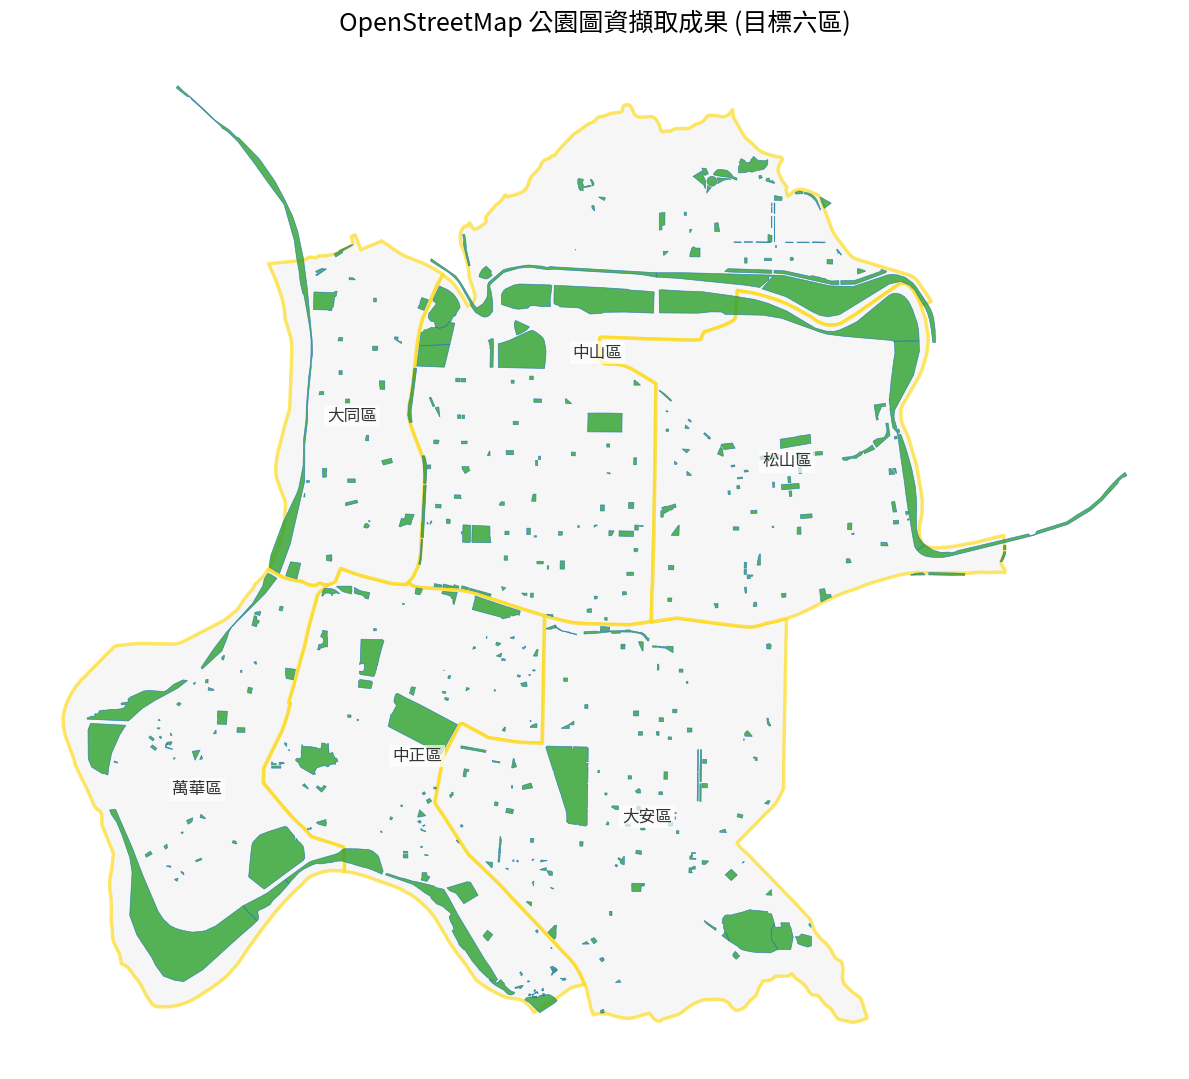

In [ ]:
# ==========================================
# 3. 介接 OSM API 獲取公園圖資
# ==========================================
print("📡 正在向 OpenStreetMap 抓取公園圖資 (需稍候片刻)...")
tags = {'leisure': 'park'}

try:
    parks_osm = ox.features_from_polygon(boundary_polygon, tags)
    parks_polygons = parks_osm[parks_osm.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()
    print(f"✅ 成功獲取資料！共找到 {len(parks_polygons)} 個實體公園。")

    # --- 3.1 匯出空間資料 (GeoPackage) ---
    print("💾 正在匯出公園幾何資料 (GPKG 格式)...")
    out_gpkg_path = os.path.join(OUTPUT_DIR, "OSM_Parks_Taipei.gpkg")

    # --- 3.2 匯出空間資料 (GeoJSON) ---
    out_geojson_path = os.path.join(OUTPUT_DIR, "OSM_Parks_Taipei.geojson")
    parks_polygons.to_file(out_geojson_path, driver="GeoJSON")
    print(f"📦 公園圖資已儲存至 (GeoJSON): {out_geojson_path}")

    # 存檔前防呆處理：將 OSM 容易出現的 List/Dict 格式轉為字串，避免 GeoPandas 存檔報錯
    for col in parks_polygons.columns:
        if parks_polygons[col].apply(lambda x: isinstance(x, (list, dict))).any():
            parks_polygons[col] = parks_polygons[col].astype(str)

    parks_polygons.to_file(out_gpkg_path, driver="GPKG")
    print(f"📦 公園圖資已儲存至: {out_gpkg_path}")

except Exception as e:
    print(f"❌ 介接或匯出 OSM 資料發生錯誤: {e}")

# ==========================================
# 4. 繪製並匯出高畫質圖檔
# ==========================================
print("🎨 正在繪製並輸出空間分佈圖檔...")

fig, ax = plt.subplots(figsize=(12, 12))

# 繪製六大行政區底圖
district_bounds.plot(ax=ax, facecolor='#f0f0f0', edgecolor='#FFD700', linewidth=2.5, alpha=0.6)

# 疊加 OSM 公園
if 'parks_polygons' in locals() and not parks_polygons.empty:
    parks_polygons.plot(ax=ax, facecolor='#2ca02c', edgecolor='#1f77b4', linewidth=0.5, alpha=0.8)

# 加上行政區名稱標籤
for idx, row in district_bounds.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, idx, fontsize=12, fontweight='bold',
            ha='center', va='center', color='#333333',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

ax.set_title("OpenStreetMap 公園圖資擷取成果 (目標六區)", fontsize=18, fontweight='bold')
ax.axis('off')
plt.tight_layout()

# --- 4.1 將繪製的圖片輸出存檔 ---
out_png_path = os.path.join(OUTPUT_DIR, "OSM_Parks_Distribution.png")
# dpi=300 代表輸出高畫質列印等級，bbox_inches='tight' 代表自動裁切多餘白邊
plt.savefig(out_png_path, dpi=300, bbox_inches='tight')
print(f"🖼️ 地圖影像已儲存至: {out_png_path}")

plt.show()

##介接OSM路網資料並進行分段buffer處理

### 微觀道路廊道分析 - 第一步：環境初始化與 OSM 路網擷取

本區塊為分析的基礎準備階段，主要執行以下任務：
1. **環境與字體設定**：載入必要套件，並設定中文字型以防後續繪圖亂碼。
2. **界定目標範圍**：讀取村里 SHP 檔案，篩選出大同、萬華、中山、中正、大安、松山六區，並融合 (Dissolve) 出一個精確的邊界多邊形 (Boundary Polygon)。

In [ ]:
import os
import warnings
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import osmnx as ox

# ==========================================
# 0. 環境設定與屏蔽警告
# ==========================================
warnings.filterwarnings("ignore", category=UserWarning)
print("⚙️ 正在初始化環境...")

font_path = '/tmp/NotoSansTC.otf'
if not os.path.exists(font_path):
    !wget -q -O {font_path} https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Noto Sans CJK TC'
plt.rcParams['axes.unicode_minus'] = False

OUTPUT_DIR = "/content/drive/MyDrive/EPM_Final/道路路網_精細版"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"📁 已建立輸出資料夾: {OUTPUT_DIR}")

# ==========================================
# 1. 定義六大行政區範圍 (空間過濾器)
# ==========================================
print("🗺️ 正在建立行政區邊界過濾器...")
shp_path = "/content/drive/MyDrive/GIS_data/全台村里界shp/VILLAGE_NLSC_121_1150306.shp"
gdf_villages = gpd.read_file(shp_path)

gdf_villages['COUNTYNAME'] = gdf_villages['COUNTYNAME'].str.replace('台北市', '臺北市')
gdf_villages['TOWNNAME'] = gdf_villages['TOWNNAME'].str.replace('台', '臺')

target_districts = ['大安區']#'大同區', '萬華區', '中山區', '中正區','松山區'
gdf_target = gdf_villages[(gdf_villages['COUNTYNAME'] == '臺北市') &
                          (gdf_villages['TOWNNAME'].isin(target_districts))].copy()

# 獲取大範圍多邊形 (WGS84 用於 OSM 抓取, TWD97 用於後續公尺運算)
boundary_poly_wgs84 = gdf_target.to_crs(epsg=4326).dissolve().geometry.iloc[0]
boundary_poly_twd97 = gdf_target.to_crs(epsg=3826).dissolve().geometry.iloc[0]
print("✅ 邊界建立完成！")

⚙️ 正在初始化環境...
🗺️ 正在建立行政區邊界過濾器...
✅ 邊界建立完成！
📡 正在向 OSM 發送自訂請求，擷取路網資料 (請稍候，可能需要一至兩分鐘)...
   -> 正在擷取平面車道骨幹...
   -> 正在擷取慢行附屬路網...
✅ OSM 抓取成功！取得 1960 段主車道，9763 段慢行路段。


### 微觀道路廊道分析 - 終極版步驟一：全路網一次性擷取與清理

捨棄以往分層抓取的做法，我們這次使用廣泛的過濾器 (Filter) 將區域內「所有實體平面路徑」一次性抓下來。
1. **全類型擷取**：包含主幹道、生活巷弄、以及所有慢行道 (footway, cycleway, path等)。
2. **排除非平面設施**：精準剔除高架橋 (`bridge`)、地下道 (`tunnel`) 以及系統交流連絡道 (`*_link`)。
3. **資料清洗**：在剛下載完成時，立刻將 OSM 容易產生的陣列 (List) 屬性清理乾淨，為後續的空間分類做準備。

In [ ]:
print("📡 正在向 OSM 發送「全類型路網」擷取請求 (這會抓取所有大街小巷與步道)...")

# ==========================================
# 1. 定義全類型過濾器 (排除橋樑、隧道與聯絡道)
# ==========================================
# 包含：primary~tertiary(大路), residential~service(小路), footway~path(慢行道)
cf_all = (
    '["highway"~"primary|secondary|tertiary|residential|living_street|service|unclassified|footway|cycleway|pedestrian|path"]'
    '["highway"!~".*_link"]'
    '["bridge"!~"yes"]["tunnel"!~"yes"]'
)

G_all = ox.graph_from_polygon(boundary_poly_wgs84, custom_filter=cf_all, simplify=True)
nodes_all, edges_all = ox.graph_to_gdfs(G_all)

# ==========================================
# 2. 徹底清理 OSM 陣列 (List) 屬性防呆
# ==========================================
# 若兩條路合併，OSM會把屬性變陣列，我們統一取第一個值
def clean_osm_col(val):
    if isinstance(val, list): return val[0]
    return val

edges_all['highway'] = edges_all['highway'].apply(clean_osm_col)
if 'width' in edges_all.columns:
    edges_all['width'] = edges_all['width'].apply(clean_osm_col)

# 轉換為 TWD97 (EPSG:3826) 供後續精確計算
edges_all_twd97 = edges_all.reset_index(drop=True).to_crs(epsg=3826)

print(f"✅ 抓取並清洗完成！總共取得 {len(edges_all_twd97)} 段平面路徑。")

📡 正在向 OSM 發送「全類型路網」擷取請求 (這會抓取所有大街小巷與步道)...
✅ 抓取並清洗完成！總共取得 26463 段平面路徑。


### 微觀道路廊道分析 - 終極版步驟二：主從拓撲吸收與獨立緩衝生成

實踐「大幹道為主，小路/步道為輔」的空間吸附邏輯：
1. **主從分類**：將路網拆分為「大幹道 (Major)」與「其他道路 (Others，含巷弄與慢行道)」。
2. **偵測與吸附 (Spatial Intersection)**：
   * 大幹道向外擴張 8 公尺形成「雷達區」。
   * 若「其他道路」落在雷達區內，則將其視為附屬設施，**不另外繪製多邊形**，而是將其屬性記錄給大幹道，並使大幹道的緩衝區變得更寬 (例如有步道再外推3m)。
3. **獨立生成**：
   * 若「其他道路」完全沒有被任何大幹道雷達掃到，則視為「獨立路段 (如公園內步道)」，賦予其專屬的微型緩衝區並保留為分析單元。
4. **合併圖層**：將「吸附後長胖的大幹道」與「獨立的其他道路」合併，完成完美的分析廊道。

📐 正在執行主從空間吸附與動態緩衝生成 (治本修正版：保留屬性 + 畫圖檢驗)...
🔍 正在以「動態超大範圍」掃描大幹道周邊路網...


/tmp/ipykernel_10098/536755342.py:70: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  edges_major['has_footway'] = edges_major['has_footway'].fillna(False)
/tmp/ipykernel_10098/536755342.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  edges_major['has_cycleway'] = edges_major['has_cycleway'].fillna(False)


🚧 正在產出高對比檢核地圖...


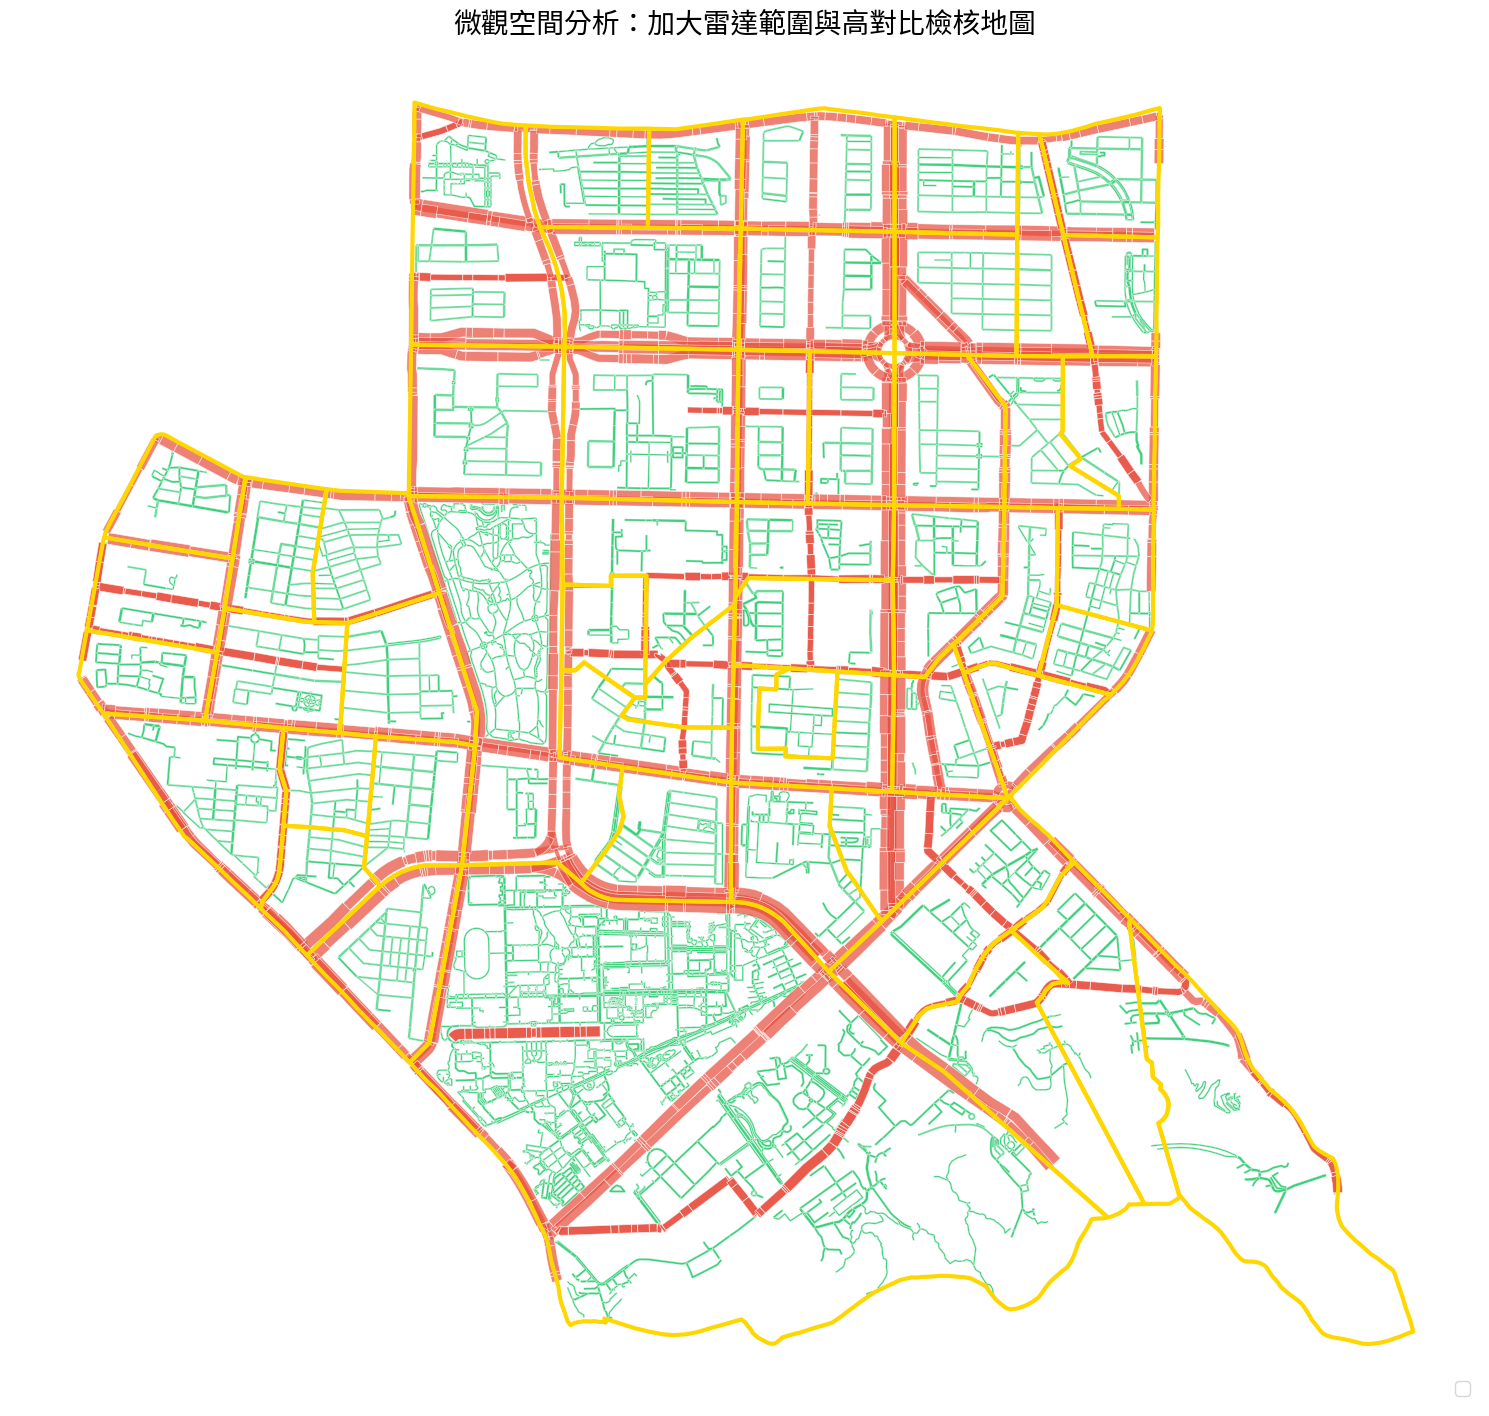

✅ 治本修正完成！屬性表中已確實包含 has_footway 與 has_cycleway。


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

print("📐 正在執行主從空間吸附與動態緩衝生成 (治本修正版：保留屬性 + 畫圖檢驗)...")

# ==========================================
# 1. 建立路寬推估邏輯與分類
# ==========================================
WIDTH_MAP = {
    'primary': 15, 'secondary': 12, 'tertiary': 8,
    'residential': 6, 'living_street': 5, 'service': 4, 'unclassified': 4,
    'footway': 2, 'cycleway': 2, 'pedestrian': 3, 'path': 2
}

def estimate_width(row):
    if 'width' in row and pd.notnull(row['width']):
        try: return float(row['width'])
        except: pass
    return WIDTH_MAP.get(row['highway'], 4)

edges_all_twd97['est_width'] = edges_all_twd97.apply(estimate_width, axis=1)

major_types = ['primary', 'secondary', 'tertiary']
edges_major = edges_all_twd97[edges_all_twd97['highway'].isin(major_types)].copy()
edges_other = edges_all_twd97[~edges_all_twd97['highway'].isin(major_types)].copy()

edges_major['major_id'] = range(len(edges_major))
edges_other['other_id'] = range(len(edges_other))

# ==========================================
# 2. 建立大幹道雷達區
# ==========================================
def get_radar_extra(hw):
    if hw == 'primary': return 12.0
    if hw == 'secondary': return 10.0
    return 8.0

edges_major['radar_extra'] = edges_major['highway'].apply(get_radar_extra)

search_gdf = edges_major[['major_id', 'geometry']].copy()
search_gdf['geometry'] = search_gdf.geometry.buffer((edges_major['est_width']/2) + edges_major['radar_extra'], cap_style=2)

print("🔍 正在以「動態超大範圍」掃描大幹道周邊路網...")
covered_join = gpd.sjoin(edges_other, search_gdf, how='inner', predicate='intersects')

# ==========================================
# 3. 處理「被吸附」的道路 ➔ 記錄 has_footway / has_cycleway
# ==========================================
covered_types = covered_join.groupby('major_id')['highway'].apply(list).reset_index()

def calc_extra_buf(types_list):
    extra = 3.0
    if any(t in types_list for t in ['footway', 'pedestrian', 'path']): extra += 4.0
    if 'cycleway' in types_list: extra += 3.0
    if any(t in types_list for t in ['residential', 'service', 'living_street', 'unclassified']): extra += 3.0
    return extra

# 計算擴張寬度
covered_types['extra_buf'] = covered_types['highway'].apply(calc_extra_buf)

# 治本：明確產生布林值欄位，記錄是否吸附到慢行設施
covered_types['has_footway'] = covered_types['highway'].apply(lambda x: any(t in x for t in ['footway', 'pedestrian', 'path']))
covered_types['has_cycleway'] = covered_types['highway'].apply(lambda x: 'cycleway' in x)

edges_major = edges_major.merge(covered_types[['major_id', 'extra_buf', 'has_footway', 'has_cycleway']], on='major_id', how='left')

# 補足沒掃到附屬設施的路段屬性
edges_major['extra_buf'] = edges_major['extra_buf'].fillna(3.0)
edges_major['has_footway'] = edges_major['has_footway'].fillna(False)
edges_major['has_cycleway'] = edges_major['has_cycleway'].fillna(False)

edges_major['corridor_radius'] = (edges_major['est_width']/2) + edges_major['extra_buf']
edges_major['initial_buffer'] = edges_major.geometry.buffer(edges_major['corridor_radius'], cap_style=2)

# ==========================================
# 4. 處理「未被覆蓋 (獨立)」的道路
# ==========================================
independent_others = edges_other[~edges_other['other_id'].isin(covered_join['other_id'])].copy()

# 治本：判定自己本身的 highway 類型
independent_others['has_footway'] = independent_others['highway'].isin(['footway', 'pedestrian', 'path'])
independent_others['has_cycleway'] = independent_others['highway'] == 'cycleway'

independent_others['corridor_radius'] = (independent_others['est_width']/2) + 1.5
independent_others['initial_buffer'] = independent_others.geometry.buffer(independent_others['corridor_radius'], cap_style=2)

# ==========================================
# 5. 合併兩者並輸出高對比預覽地圖
# ==========================================
print("🚧 正在產出高對比檢核地圖...")
final_corridors = pd.concat([
    edges_major.set_geometry('initial_buffer'),
    independent_others.set_geometry('initial_buffer')
], ignore_index=True)

fig, ax = plt.subplots(figsize=(15, 15))

# 大幹道廊道 (鮮豔紅色)
final_corridors[final_corridors['highway'].isin(major_types)].plot(
    ax=ax, color='#e74c3c', alpha=0.7, edgecolor='white', linewidth=0.5, zorder=2, label='大幹道廊道 (已吸附周邊)'
)

# 獨立的其他道路 (亮綠色)
final_corridors[~final_corridors['highway'].isin(major_types)].plot(
    ax=ax, color='#2ecc71', alpha=0.7, edgecolor='white', linewidth=0.3, zorder=1, label='獨立巷弄與純步道'
)

# 如果有村里界線可以畫上去
if 'gdf_target' in locals():
    gdf_target.to_crs(epsg=3826).plot(ax=ax, facecolor='none', edgecolor='#FFD700', linewidth=3, zorder=5)

ax.set_title("微觀空間分析：加大雷達範圍與高對比檢核地圖", fontsize=20, fontweight='bold')
ax.legend(fontsize=14, loc='lower right')
ax.axis('off')
plt.tight_layout()
plt.show()

print("✅ 治本修正完成！屬性表中已確實包含 has_footway 與 has_cycleway。")

### 微觀道路廊道分析 - 終極版步驟三：實體建物裁切 (Building Clipping) 與成果封裝

本區塊為微觀尺度分析的核心物理限制處理。我們將利用實體建物框來裁切剛才產生的「全階層路廊」，確保分析範圍不會穿透兩側的建築物，還原真實的街道剩餘空間。

**執行重點：**
1. **建物與街樹過濾**：載入台北市 3D 建物框與街樹清冊，利用大安區邊界進行空間遮罩 (Mask)，節省記憶體。
2. **空間差集 (Difference)**：
   * 使用 `unary_union` 將大安區內所有建物融合為一個整體的「建築障礙物」。
   * 將步驟二產生的 `final_corridors` (包含大幹道與獨立巷弄) 與建築障礙物進行差集運算，挖空重疊部分。
3. **成果匯出與檢驗**：將具有真實物理邊界的精細路廊儲存為 `GPKG` 與 `GeoJSON`，並疊加街樹繪製最終檢核地圖。

🏠 正在載入實體空間圖資 (建物與街樹)...
   -> 成功載入目標區域內共 19682 棟建物。
   -> 目標區域內共有 23192 棵樹。
✂️ 正在進行建物邊緣裁剪 (此步驟需要密集幾何運算，請稍候約 1-3 分鐘)...


/tmp/ipykernel_10098/1085096336.py:37: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bui_union = gdf_buildings.unary_union


💾 正在匯出最終精細版路廊多邊形...
📦 已成功儲存成果至:
   - /content/drive/MyDrive/EPM_Final/道路路網_精細版/Taipei_Enriched_Corridors_Clipped.gpkg
   - /content/drive/MyDrive/EPM_Final/道路路網_精細版/Taipei_Enriched_Corridors_Clipped.geojson
🎨 正在產生最終裁切檢核疊圖...


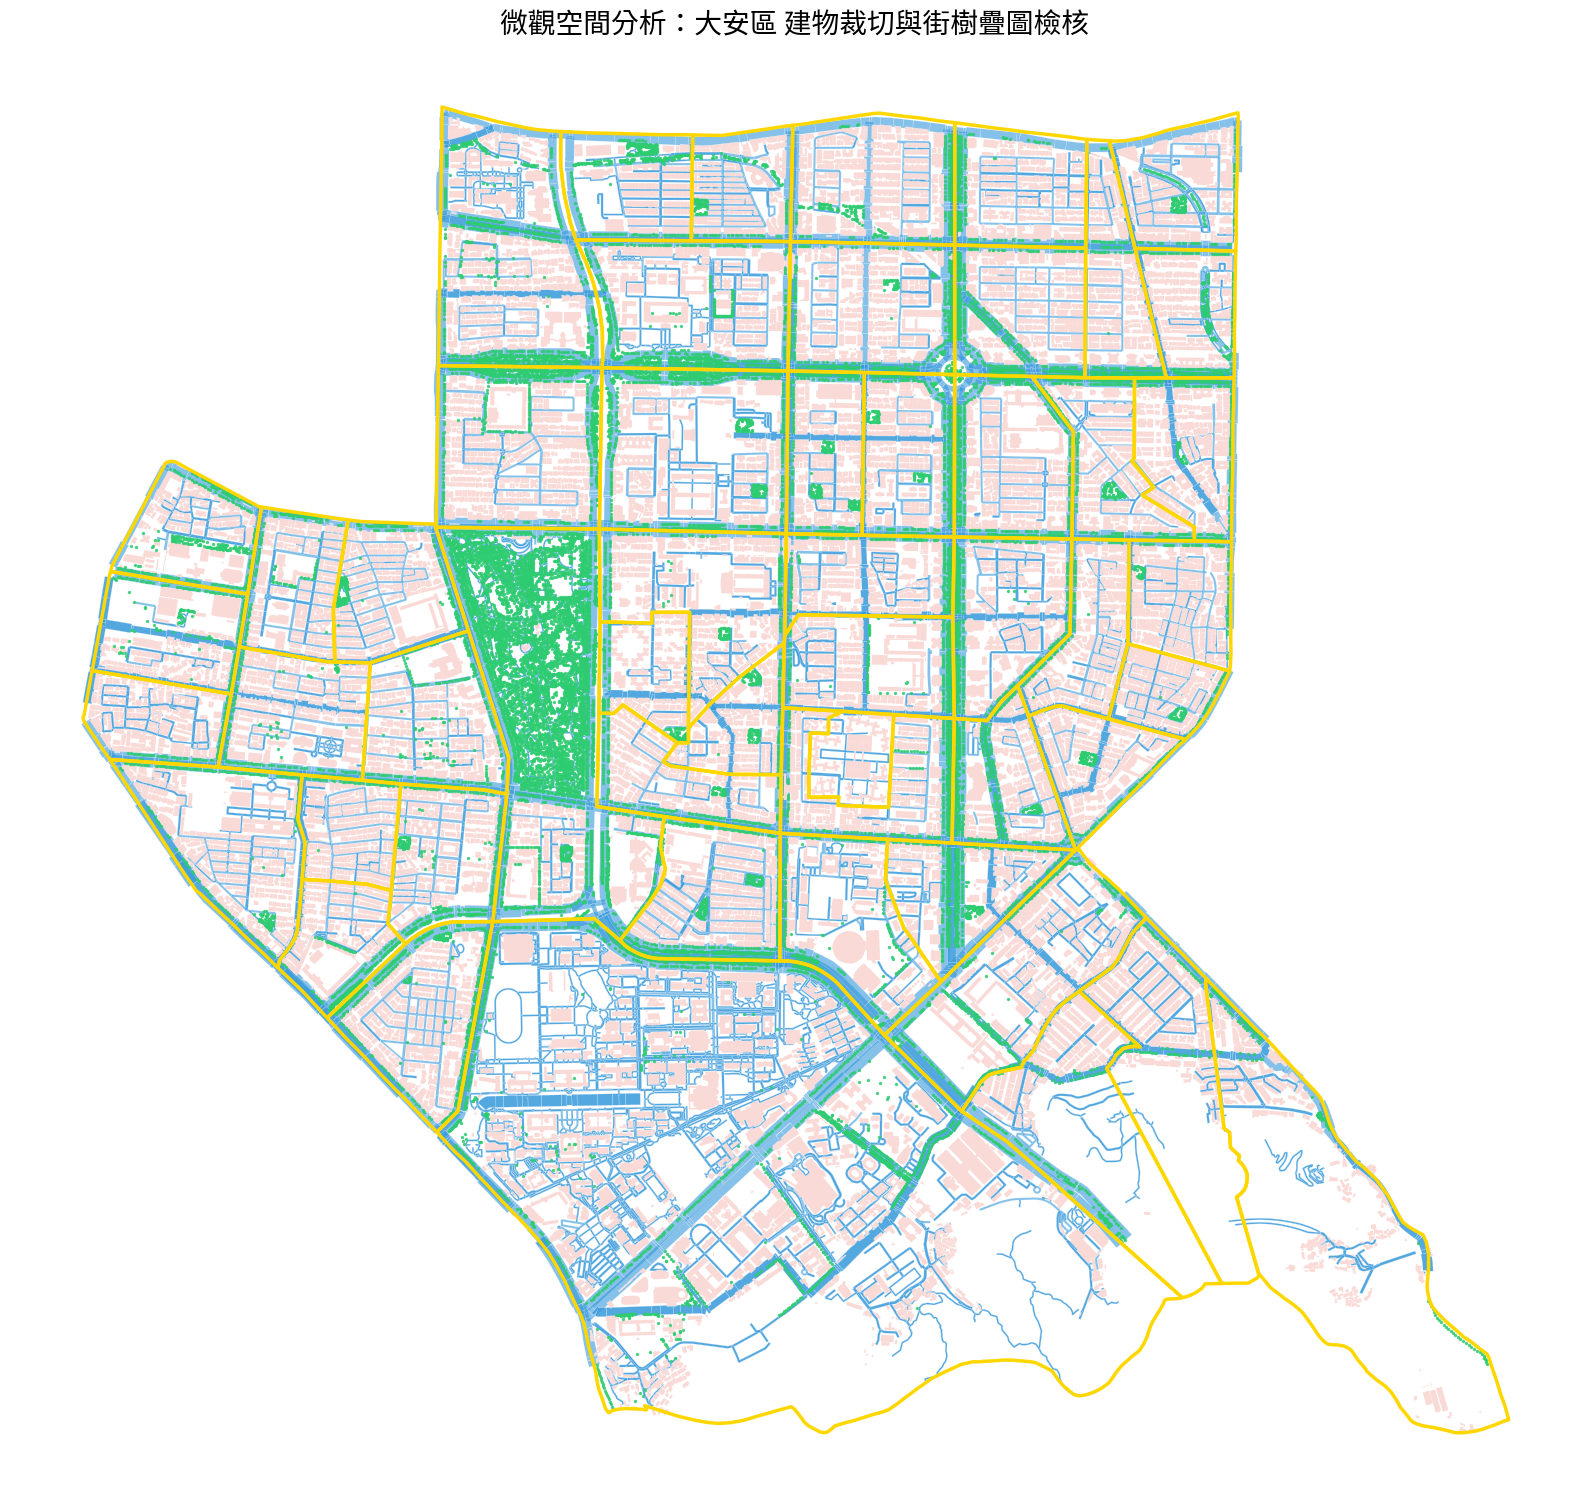

🎉 治本修正完畢！現在產出的檔案具備最標準的 geometry 欄位！


In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import os
from shapely.ops import unary_union

print("🏠 正在載入實體空間圖資 (建物與街樹)...")

# ==========================================
# 1. 讀取並過濾建物框圖資
# ==========================================
bui_shp_path = "/content/drive/MyDrive/GIS_data/台北市3D建物框/A_1133BUIE.shp"
gdf_buildings = gpd.read_file(bui_shp_path, mask=gdf_target)
gdf_buildings = gdf_buildings.to_crs(epsg=3826)
print(f"   -> 成功載入目標區域內共 {len(gdf_buildings)} 棟建物。")

# ==========================================
# 2. 讀取並轉換樹木清冊
# ==========================================
tree_csv_path = "/content/drive/MyDrive/EPM_Final/樹木清冊/台北市公園處&街樹完整_清理後.csv"
df_trees = pd.read_csv(tree_csv_path, low_memory=False)

gdf_trees = gpd.GeoDataFrame(
    df_trees,
    geometry=gpd.points_from_xy(df_trees['TWD97X座標'], df_trees['TWD97Y座標']),
    crs="EPSG:3826"
)

gdf_trees = gdf_trees[gdf_trees.intersects(boundary_poly_twd97)]
print(f"   -> 目標區域內共有 {len(gdf_trees)} 棵樹。")

# ==========================================
# 3. 執行建物空間裁切 (Difference) ★ 治本修正幾何名稱
# ==========================================
print("✂️ 正在進行建物邊緣裁剪 (此步驟需要密集幾何運算，請稍候約 1-3 分鐘)...")

bui_union = gdf_buildings.unary_union

def clip_buildings(geom):
    if geom.intersects(bui_union):
        return geom.difference(bui_union)
    return geom

# ★ 治本關鍵：將裁切結果直接存入標準的 'geometry' 欄位中
final_corridors['geometry'] = final_corridors.geometry.apply(clip_buildings)

# 明確告訴 GeoPandas，我們的主幾何就是這個標準的 'geometry'
edges_final = final_corridors.set_geometry('geometry')

# ==========================================
# 4. 清理屬性並匯出圖資 ★ 治本修正：絕不丟掉 geometry
# ==========================================
print("💾 正在匯出最終精細版路廊多邊形...")
out_gpkg = os.path.join(OUTPUT_DIR, "Taipei_Enriched_Corridors_Clipped.gpkg")
out_json = os.path.join(OUTPUT_DIR, "Taipei_Enriched_Corridors_Clipped.geojson")

# 這裡移除了 'geometry'，確保它不會被刪掉；加入了不再需要的 'initial_buffer' 等暫存欄位
cols_to_drop = ['initial_buffer', 'osmid', 'nodes', 'reversed', 'lanes', 'maxspeed', 'major_id', 'other_id']
export_gdf = edges_final.drop(columns=[c for c in cols_to_drop if c in edges_final.columns], errors='ignore')

# 防呆轉字串
for col in export_gdf.columns:
    if export_gdf[col].apply(lambda x: isinstance(x, (list, dict))).any():
        export_gdf[col] = export_gdf[col].astype(str)

export_gdf.to_file(out_gpkg, driver="GPKG")
export_gdf.to_file(out_json, driver="GeoJSON")
print(f"📦 已成功儲存成果至:\n   - {out_gpkg}\n   - {out_json}")

# ==========================================
# 5. 繪製最終視覺檢驗地圖
# ==========================================
print("🎨 正在產生最終裁切檢核疊圖...")
fig, ax = plt.subplots(figsize=(16, 16))

gdf_buildings.plot(ax=ax, color='#f5b7b1', alpha=0.5, zorder=1, label='實體建物')
export_gdf.plot(ax=ax, color='#3498db', alpha=0.6, edgecolor='white', linewidth=0.2, zorder=2, label='微觀路廊 (已裁切)')
gdf_trees.plot(ax=ax, color='#2ecc71', markersize=2, alpha=0.8, zorder=3, label='現有街樹')

if 'gdf_target' in locals():
    gdf_target.to_crs(epsg=3826).plot(ax=ax, facecolor='none', edgecolor='#FFD700', linewidth=2.5, zorder=4)

ax.set_title(f"微觀空間分析：{target_districts[0]} 建物裁切與街樹疊圖檢核", fontsize=20, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print("🎉 治本修正完畢！現在產出的檔案具備最標準的 geometry 欄位！")

### 微觀道路廊道分析 - 最終步：空間統計與互動式網頁地圖 (Folium)

本區塊將產出可供滑鼠互動、圖層開關的動態檢核地圖，並進行第一項綠化指標的空間統計。
1. **空間統計 (Spatial Aggregation)**：利用空間交集 (`sjoin`)，計算每一段裁切後的路段多邊形內部，究竟涵蓋了幾棵現有街樹，並將 `tree_count` (樹木數量) 寫入該路段的屬性表中。
2. **座標系統轉換**：將原本用於精確公尺計算的 TWD97 (EPSG:3826) 轉換為網頁地圖通用的 WGS84 (EPSG:4326) 經緯度座標。
3. **Folium 互動地圖封裝**：
   * 建立帶有底圖的網頁地圖。
   * 加入「大幹道」與「獨立巷弄/步道」圖層，並設定 Hover Tooltip，讓滑鼠移過去時能顯示路寬、是否有步道、以及樹木數量。
   * 加入「街樹點位」圖層，並開啟圖層控制 (Layer Control) 面板。

In [ ]:
import folium
import json
import geopandas as gpd
from folium import plugins

print("🌳 正在計算每個路廊多邊形內的樹木數量 (Spatial Aggregation)...")

# ==========================================
# 1. 空間統計：計算路廊內的樹木數量
# ==========================================
# 給予一個絕對唯一的 ID 方便統計
export_gdf['corridor_id'] = range(len(export_gdf))

# ★ 關鍵修正：動態抓取當前的幾何欄位名稱 (目前是 'clipped_corridor')
geom_col = export_gdf.geometry.name

# 執行空間交集：找出哪些樹落在哪些路廊內 (前提：兩者目前都是 TWD97 座標)
trees_in_corridor = gpd.sjoin(gdf_trees, export_gdf[['corridor_id', geom_col]], how='inner', predicate='intersects')

# 分組計算每個路廊的樹木總數
tree_counts = trees_in_corridor.groupby('corridor_id').size().reset_index(name='tree_count')

# 將統計結果合併回原本的路廊屬性表中
export_gdf = export_gdf.merge(tree_counts, on='corridor_id', how='left')
export_gdf['tree_count'] = export_gdf['tree_count'].fillna(0).astype(int) # 沒樹的地方補 0

print("🗺️ 正在轉換座標系統以生成互動地圖...")
# ==========================================
# 2. 轉換座標為 WGS84 (Folium 網頁地圖強制要求經緯度)
# ==========================================
export_wgs84 = export_gdf.to_crs(epsg=4326)
trees_wgs84 = gdf_trees.to_crs(epsg=4326)

# ==========================================
# 3. 建立 Folium 互動式地圖
# ==========================================
# 計算視角中心點
center_lat = export_wgs84.geometry.centroid.y.mean()
center_lon = export_wgs84.geometry.centroid.x.mean()

# 建立基礎地圖 (使用淺色底圖凸顯資料)
m = folium.Map(location=[center_lat, center_lon], zoom_start=14, tiles='CartoDB positron')

print("🎨 正在封裝圖層與 Hover 資訊...")

# --- 圖層 1: 大幹道路廊 ---
major_types = ['primary', 'secondary', 'tertiary']
major_corridors = export_wgs84[export_wgs84['highway'].isin(major_types)]

folium.GeoJson(
    major_corridors,
    name="大幹道廊道 (Major Corridors)",
    style_function=lambda feature: {
        'fillColor': '#e74c3c', 'color': '#c0392b', 'weight': 1, 'fillOpacity': 0.6
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['highway', 'est_width', 'has_footway', 'has_cycleway', 'tree_count'],
        aliases=['道路等級:', '推估路寬 (m):', '含人行道:', '含單車道:', '🌳 涵蓋樹木數:'],
        style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;")
    )
).add_to(m)

# --- 圖層 2: 獨立巷弄與純步道 ---
minor_corridors = export_wgs84[~export_wgs84['highway'].isin(major_types)]

folium.GeoJson(
    minor_corridors,
    name="獨立巷弄與步道 (Minor/Paths)",
    style_function=lambda feature: {
        'fillColor': '#3498db', 'color': '#2980b9', 'weight': 1, 'fillOpacity': 0.6
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['highway', 'est_width', 'has_footway', 'has_cycleway', 'tree_count'],
        aliases=['道路等級:', '推估路寬 (m):', '含人行道:', '含單車道:', '🌳 涵蓋樹木數:'],
        style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;")
    )
).add_to(m)

# --- 圖層 3: 街樹點位 ---
# 使用 FeatureGroup 讓點位可以被整批開關
tree_group = folium.FeatureGroup(name="現有街樹點位 (Tree Locations)", show=False) # 預設關閉，避免畫面太亂

# 將樹木點位轉為 GeoJSON 格式加入 (使用 CircleMarker 效能較好)
for idx, row in trees_wgs84.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=2, color='#2ecc71', fill=True, fillOpacity=0.8,
        tooltip="街樹"
    ).add_to(tree_group)

tree_group.add_to(m)

# 加入圖層控制器
folium.LayerControl(collapsed=False).add_to(m)

print("🎉 互動式地圖生成完畢！請盡情用滑鼠探索大安區的綠化路廊！")
# 在 Colab 中直接顯示地圖
m

🌳 正在計算每個路廊多邊形內的樹木數量 (Spatial Aggregation)...


NameError: name 'export_gdf' is not defined